# 01 Curve Build

This notebook builds a Treasury zero curve from the raw par-yield input and prepares the benchmark discount curve used throughout the valuation workflow.

The starting point is a daily Treasury par-yield table. The purpose of this step is to convert those quoted market yields into discount factors and zero rates that can be applied consistently across every bond in the universe.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.curve import build_zero_curve, format_curve_table, load_treasury_curve

In [3]:
curve_path = PROJECT_ROOT / "data" / "raw" / "treasury_curve.csv"
history = load_treasury_curve(curve_path)
history.tail()

,date,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,30Y
295,1991-03-08,6.16,6.25,6.41,7.08,7.35,7.77,8.01,8.13,8.30
296,1991-03-11,6.08,6.21,6.37,7.05,7.30,7.71,7.94,8.06,8.23
297,1991-03-12,6.05,6.19,6.38,7.07,7.33,7.74,7.98,8.09,8.26
298,1991-03-13,6.02,6.12,6.30,7.00,7.23,7.67,7.91,8.02,8.20
299,1991-03-14,5.94,6.04,6.26,6.95,7.19,7.64,7.90,8.02,8.20


In [4]:
eval_date = history.iloc[-1]["date"].strftime("%Y-%m-%d")
as_of_date, zero_curve = build_zero_curve(curve_path, eval_date=eval_date)
display_curve = format_curve_table(zero_curve)
display_curve

,date,maturity_years,par_yield,discount_factor,zero_rate
0,1991-03-14,0.25,5.94,0.985367,6.0736
1,1991-03-14,0.50,6.04,0.970685,6.1312
2,1991-03-14,1.00,6.26,0.940190,6.3615
3,1991-03-14,2.00,6.95,0.871629,7.1111
4,1991-03-14,3.00,7.19,0.808097,7.3608
5,1991-03-14,5.00,7.64,0.683783,7.8987
6,1991-03-14,7.00,7.90,0.576222,8.1936
7,1991-03-14,10.00,8.02,0.449650,8.3210
8,1991-03-14,30.00,8.20,0.077710,8.8890


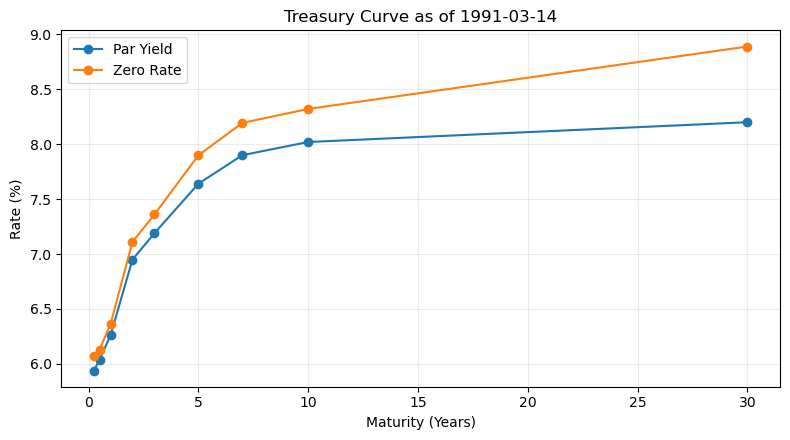

In [5]:
plt.figure(figsize=(8, 4.5))
plt.plot(display_curve["maturity_years"], display_curve["par_yield"], marker="o", label="Par Yield")
plt.plot(display_curve["maturity_years"], display_curve["zero_rate"], marker="o", label="Zero Rate")
plt.xlabel("Maturity (Years)")
plt.ylabel("Rate (%)")
plt.title(f"Treasury Curve as of {as_of_date.date()}")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

A production curve build would usually use richer interpolation, more instruments, and convention handling. For this project, the simplified bootstrap is enough to create a consistent benchmark curve and show how market inputs feed the rest of the pricing process.